# 1.读取MNIST数据集

In [2]:
import time
from sklearn.metrics import accuracy_score
from product_quantization import ProductQuantizationKNN
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np

# Define a function to load data using torchvision
def load_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(trainset), shuffle=False)
    testloader = torch.utils.data.DataLoader(testset, batch_size=len(testset), shuffle=False)

    train_data, train_labels = next(iter(trainloader))
    test_data, test_labels = next(iter(testloader))

    train_data = train_data.view(train_data.shape[0], -1).numpy()
    train_labels = train_labels.numpy().reshape(-1, 1)
    test_data = test_data.view(test_data.shape[0], -1).numpy()
    test_labels = test_labels.numpy().reshape(-1, 1)

    train = np.hstack((train_data, train_labels))
    test = np.hstack((test_data, test_labels))

    return train, test

train, test = load_data()

train_labels = train[:, -1]
train_data = train[:, :-1]
test_labels = test[:, -1]
test_data = test[:, :-1]

print('Train features shape:', train_data.shape)
print('Train labels shape:', train_labels.shape)
print('Test features shape:', test_data.shape)
print('Test labels shape:', test_labels.shape)


Train features shape: (60000, 784)
Train labels shape: (60000,)
Test features shape: (10000, 784)
Test labels shape: (10000,)


# 2.计算PQKNN、KNN、KNN(parallel)压缩数据、预测的时间和准确率

In [6]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Initialize ProductQuantizationKNN and sklearn's KNeighborsClassifier
k = 10
pqknn = ProductQuantizationKNN(7, 4)

# Compressing train_data using ProductQuantizationKNN
start = time.time()
pqknn.compress(train_data, train_labels)
end = time.time()
pqknn_compress_time = end - start
print('Compressing the train_data to PQKNN classifier took ' + str(end - start) + ' seconds.')
print('Compressed data shape:', pqknn.compressed_data.shape)
print('Compressed data in bytes:', pqknn.compressed_data.nbytes)
print('Original data in bytes:', train_data.nbytes)
print('Compression factor:', train_data.nbytes / pqknn.compressed_data.nbytes)

# Predicting using ProductQuantizationKNN
start = time.time()
pqknn_preds = pqknn.predict(test_data, k)
end = time.time()
pqknn_predict_time = end - start
pqknn_accuracy = accuracy_score(test_labels, pqknn_preds) * 100

# Fitting and predicting with sklearn KNeighborsClassifier
kNN = KNeighborsClassifier(n_neighbors=k)
start = time.time()
kNN.fit(train_data, train_labels)
end = time.time()
sklearn_knn_fit_time = end - start

start = time.time()
sklearn_knn_preds = kNN.predict(test_data)
end = time.time()
sklearn_knn_predict_time = end - start
sklearn_knn_accuracy = accuracy_score(test_labels, sklearn_knn_preds) * 100

# Fitting and predicting with sklearn KNeighborsClassifier (parallel jobs)
kNN_parallel = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
start = time.time()
kNN_parallel.fit(train_data, train_labels)
end = time.time()
sklearn_knn_parallel_fit_time = end - start

start = time.time()
sklearn_knn_parallel_preds = kNN_parallel.predict(test_data)
end = time.time()
sklearn_knn_parallel_predict_time = end - start
sklearn_knn_parallel_accuracy = accuracy_score(test_labels, sklearn_knn_parallel_preds) * 100

Compressing the train_data to PQKNN classifier took 2.552306652069092 seconds.
Compressed data shape: (60000, 7)
Compressed data in bytes: 420000
Original data in bytes: 376320000
Compression factor: 896.0


# 3.结果可视化

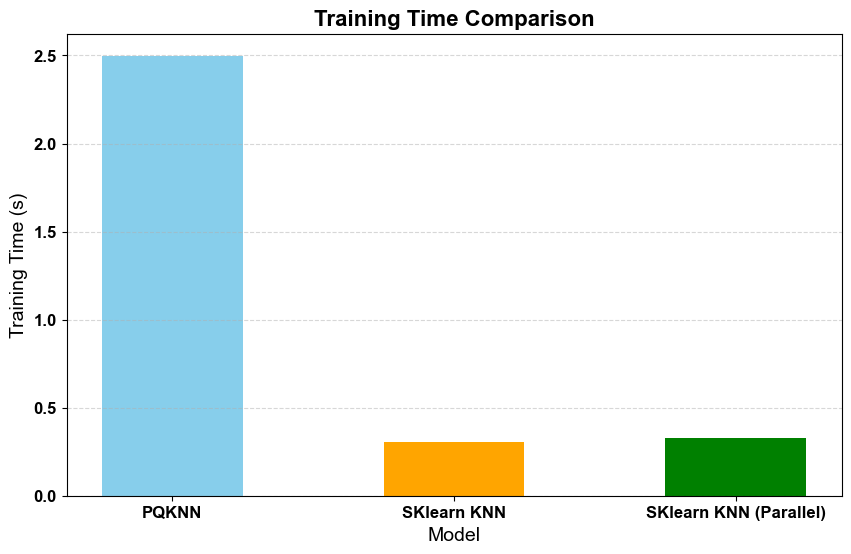

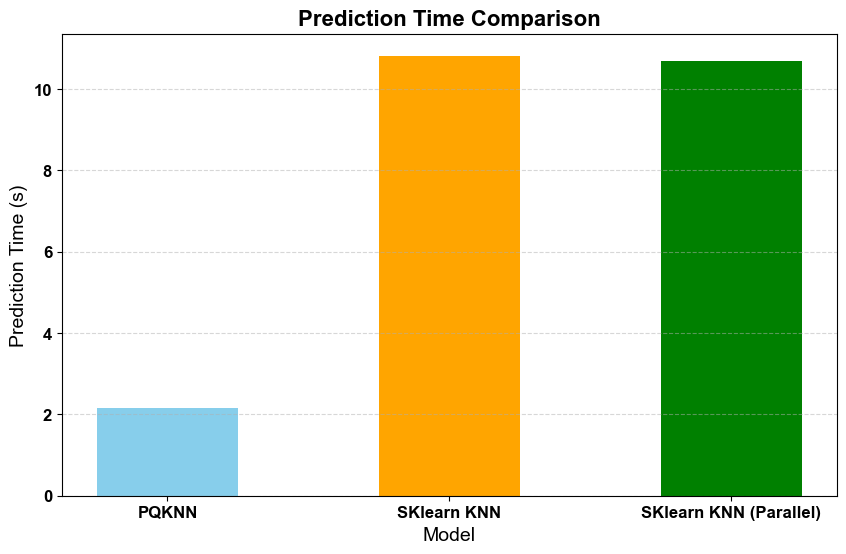

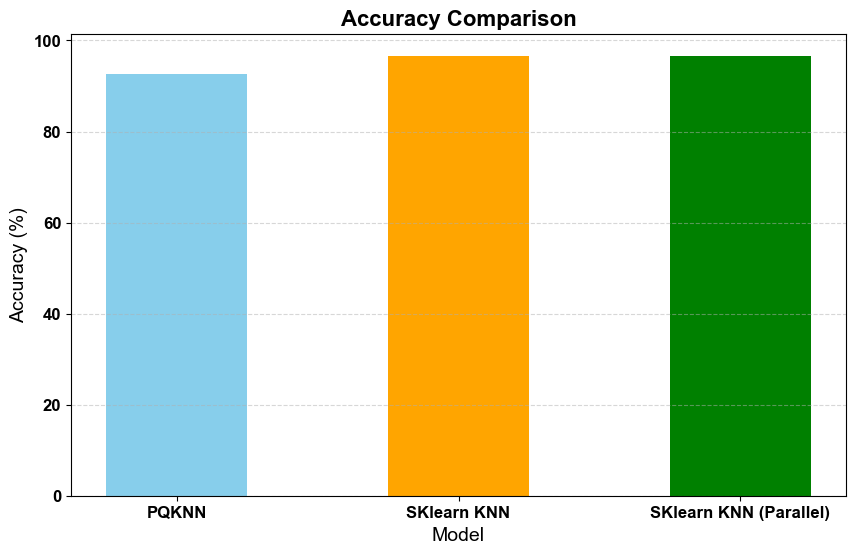

In [5]:
import matplotlib.pyplot as plt
import time

# Define labels and data for plots
labels = ['PQKNN', 'SKlearn KNN', 'SKlearn KNN (Parallel)']
train_times = [pqknn_compress_time, sklearn_knn_fit_time, sklearn_knn_parallel_fit_time]
predict_times = [pqknn_predict_time, sklearn_knn_predict_time, sklearn_knn_parallel_predict_time]
accuracies = [pqknn_accuracy, sklearn_knn_accuracy, sklearn_knn_parallel_accuracy]

# Set a neutral color palette (grayscale)
colors = ['skyblue', 'orange', 'green']

# Font settings
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial', 'font.weight': 'bold'})

# Training Times Plot
plt.figure(figsize=(10, 6))
plt.bar(labels, train_times, color=colors, width=0.5)
plt.xlabel('Model', fontsize=14, color='black')
plt.ylabel('Training Time (s)', fontsize=14, color='black')
plt.title('Training Time Comparison', fontsize=16, color='black', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('./result/training_time_comparison.png')
plt.show()

# Prediction Times Plot
plt.figure(figsize=(10, 6))
plt.bar(labels, predict_times, color=colors, width=0.5)
plt.xlabel('Model', fontsize=14, color='black')
plt.ylabel('Prediction Time (s)', fontsize=14, color='black')
plt.title('Prediction Time Comparison', fontsize=16, color='black', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('./result/prediction_time_comparison.png')
plt.show()

# Accuracy Comparison Plot
plt.figure(figsize=(10,
                    6))
plt.bar(labels, accuracies, color=colors, width=0.5)
plt.xlabel('Model', fontsize=14, color='black')
plt.ylabel('Accuracy (%)', fontsize=14, color='black')
plt.title('Accuracy Comparison', fontsize=16, color='black', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('./result/accuracy_comparison.png')
plt.show()


# 4.PCA和LDA降维

Comparing classifiers with PCA...
PCA with 7 components done.
PCA with 8 components done.
PCA with 9 components done.
PCA with 10 components done.
PCA with 11 components done.
PCA with 12 components done.
PCA with 13 components done.
PCA with 14 components done.
PCA with 15 components done.
PCA with 16 components done.
PCA with 17 components done.
PCA with 18 components done.
PCA with 19 components done.
PCA with 20 components done.
PCA with 21 components done.
PCA with 22 components done.
PCA with 23 components done.
PCA with 24 components done.
PCA with 25 components done.
PCA with 26 components done.
PCA with 27 components done.
PCA with 28 components done.
PCA with 29 components done.
PCA with 30 components done.
PCA with 31 components done.
PCA with 32 components done.
PCA with 33 components done.
PCA with 34 components done.
PCA with 35 components done.
PCA with 36 components done.
PCA with 37 components done.
PCA with 38 components done.
PCA with 39 components done.
PCA with 40 

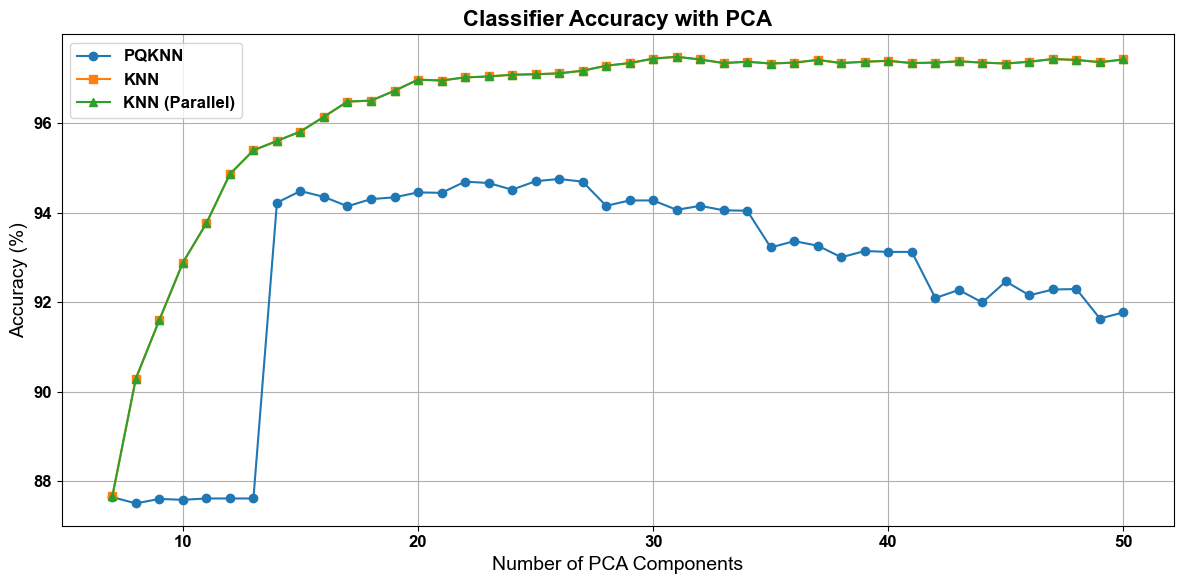

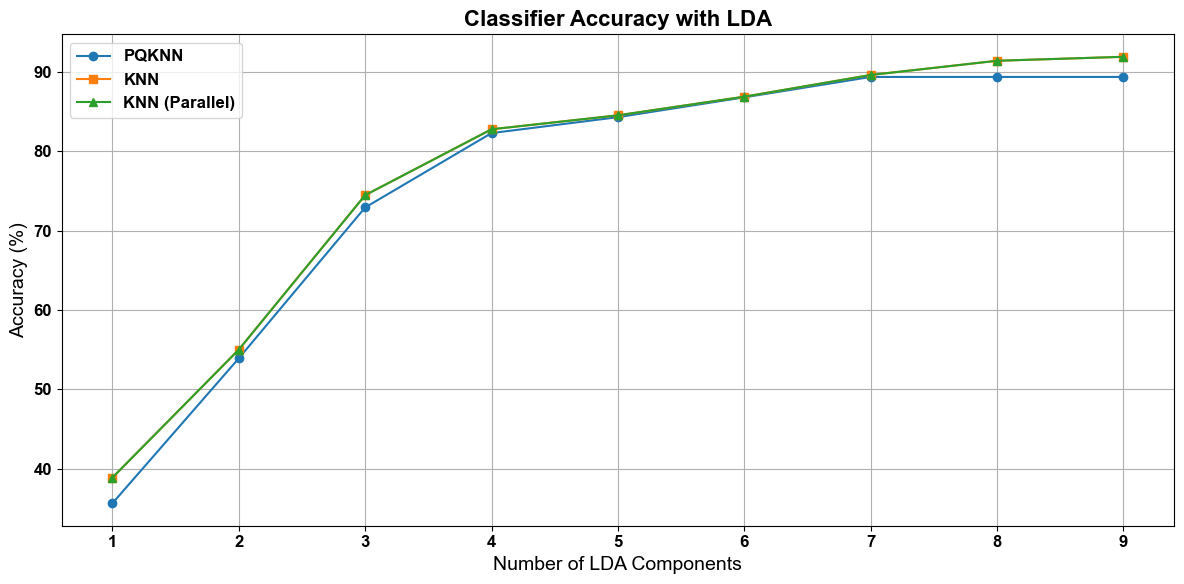

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from product_quantization import ProductQuantizationKNN
import torch
import torchvision
import torchvision.transforms as transforms

# 2. 定义降维和分类器比较函数
def compare_classifiers(dimensions, method='PCA'):
    pqknn_accuracies = []
    knn_accuracies = []
    knn_parallel_accuracies = []
    pqknn_dimensions = []  # 记录实际使用的维数

    for n_components in dimensions:
        # 降维
        if method == 'PCA':
            dr = PCA(n_components=n_components)
        elif method == 'LDA':
            dr = LDA(n_components=n_components)
        else:
            raise ValueError("Method must be 'PCA' or 'LDA'")

        dr.fit(train_data, train_labels)
        train_data_reduced = dr.transform(train_data)
        test_data_reduced = dr.transform(test_data)

        # 确保降维后的特征数不小于 1
        n_features_reduced = train_data_reduced.shape[1]
        if n_features_reduced < 1:
            print(f"Reduced features ({n_features_reduced}) less than 1, skipping...")
            continue

        # 为 PQKNN 设置合适的 m 值
        m = min(7, n_features_reduced)  # 确保 m 不大于特征数
        k_subspace = 4  # 您可以根据需要调整 k_subspace 值

        # PQKNN
        pqknn = ProductQuantizationKNN(m, k_subspace)
        pqknn.compress(train_data_reduced, train_labels)
        pqknn_preds = pqknn.predict(test_data_reduced, 10)  # 将 k 作为位置参数传递
        pqknn_accuracy = accuracy_score(test_labels, pqknn_preds) * 100
        pqknn_accuracies.append(pqknn_accuracy)
        pqknn_dimensions.append(n_components)

        # 标准 KNN
        kNN = KNeighborsClassifier(n_neighbors=10)
        kNN.fit(train_data_reduced, train_labels)
        knn_preds = kNN.predict(test_data_reduced)
        knn_accuracy = accuracy_score(test_labels, knn_preds) * 100
        knn_accuracies.append(knn_accuracy)

        # 并行 KNN
        kNN_parallel = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
        kNN_parallel.fit(train_data_reduced, train_labels)
        knn_parallel_preds = kNN_parallel.predict(test_data_reduced)
        knn_parallel_accuracy = accuracy_score(test_labels, knn_parallel_preds) * 100
        knn_parallel_accuracies.append(knn_parallel_accuracy)

        print(f"{method} with {n_components} components done.")

    return pqknn_dimensions, pqknn_accuracies, knn_accuracies, knn_parallel_accuracies

# 3. 设置降维维数范围
pca_dimensions = range(7, 51)  # PCA 降维维数从 7 到 50，确保特征数不小于 m
lda_dimensions = range(1, 10)  # LDA 降维维数从 1 到 9（类别数 - 1）

# 4. 比较分类器在 PCA 降维空间中的性能
print("Comparing classifiers with PCA...")
pca_dims, pca_pqknn_acc, pca_knn_acc, pca_knn_parallel_acc = compare_classifiers(pca_dimensions, method='PCA')

# 5. 比较分类器在 LDA 降维空间中的性能
print("Comparing classifiers with LDA...")
lda_dims, lda_pqknn_acc, lda_knn_acc, lda_knn_parallel_acc = compare_classifiers(lda_dimensions, method='LDA')

# 6. 可视化结果
# 设置字体
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial', 'font.weight': 'bold'})

# PCA 结果可视化
plt.figure(figsize=(12, 6))
plt.plot(pca_dims, pca_pqknn_acc, label='PQKNN', marker='o')
plt.plot(pca_dims, pca_knn_acc, label='KNN', marker='s')
plt.plot(pca_dims, pca_knn_parallel_acc, label='KNN (Parallel)', marker='^')
plt.xlabel('Number of PCA Components', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Classifier Accuracy with PCA', fontsize=16, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./result/pca_accuracy_comparison.png')
plt.show()

# LDA 结果可视化
plt.figure(figsize=(12, 6))
plt.plot(lda_dims, lda_pqknn_acc, label='PQKNN', marker='o')
plt.plot(lda_dims, lda_knn_acc, label='KNN', marker='s')
plt.plot(lda_dims, lda_knn_parallel_acc, label='KNN (Parallel)', marker='^')
plt.xlabel('Number of LDA Components', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Classifier Accuracy with LDA', fontsize=16, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./result/lda_accuracy_comparison.png')
plt.show()
